# Atelier – Préparation de Données Textuelles
Classification de sentiment sur des avis clients (`smart_reviews_raw.csv`).

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy import sparse

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...


True

## Partie 1 – Exploration du corpus

In [3]:
# Question 1 : Charger les données CSV
df = pd.read_csv("../data/smart_reviews_raw.csv")
df.head()


,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


In [4]:
# Question 2 : Nombre d'avis
print("Nombre d'avis :", df.shape[0])


Nombre d'avis : 1200


In [5]:
# Question 3 : Nombre de colonnes
print("Nombre de colonnes :", df.shape[1])


Nombre de colonnes : 8


In [6]:
# Question 4 : Type de chaque colonne
df.dtypes


id_avis      object
date         object
source       object
produit      object
texte        object
sentiment    object
note          int64
langue       object
dtype: object

In [7]:
# Question 5 : Valeurs manquantes
df.isnull().sum()


id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

In [8]:
# Question 6 : Quelques types de texte
print("Texte normal :", df['texte'].iloc[0])

for i in range(len(df)):
    texte = str(df['texte'].iloc[i])
    if texte.strip() == "" or texte == "nan":
        print("Texte vide (ligne", i, ") :", repr(texte))
        break

for i in range(len(df)):
    texte = str(df['texte'].iloc[i])
    if "http" in texte:
        print("Texte avec URL :", texte)
        break

for i in range(len(df)):
    texte = str(df['texte'].iloc[i])
    if "@" in texte:
        print("Texte avec mention :", texte)
        break

for i in range(len(df)):
    texte = str(df['texte'].iloc[i])
    if "#" in texte:
        print("Texte avec hashtag :", texte)
        break

for i in range(len(df)):
    texte = str(df['texte'].iloc[i])
    if re.search(r'[\U0001F300-\U0001FAFF]', texte):
        print("Texte avec emoji :", texte)
        break

for i in range(len(df)):
    texte = str(df['texte'].iloc[i])
    if texte.count("!") + texte.count("?") >= 3:
        print("Texte avec beaucoup de ponctuation :", texte)
        break

for i in range(len(df)):
    texte = str(df['texte'].iloc[i])
    if texte.isupper():
        print("Texte en majuscules :", texte)
        break

for i in range(len(df)):
    texte = str(df['texte'].iloc[i])
    if re.search(r'(.)\1{2,}', texte):
        print("Texte avec répétition de caractères :", texte)
        break


Texte normal : Très  bonne  expérience,  simple  et  efficace.
Texte vide (ligne 46 ) : 'nan'
Texte avec URL : Produit parfait, rien à signaler. https://example.com/commande/17
Texte avec mention : @client Livraison rapide et produit conforme à mes attentes.
Texte avec hashtag : Très satisfait de mon achat 👍 #avis
Texte avec emoji : Très satisfait de mon achat 👍 #avis
Texte avec beaucoup de ponctuation : Produit excellent, je suis très satisfait. !!!
Texte en majuscules : LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
Texte avec répétition de caractères : Produit excellent, je suis très satisfait. !!!


In [9]:
# Question 7 : Longueur des textes
df['longueur'] = df['texte'].fillna('').astype(str).apply(len)

print("Longueur minimale :", df['longueur'].min())
print("Longueur maximale :", df['longueur'].max())
print("Longueur moyenne :", df['longueur'].mean())
print("Médiane :", df['longueur'].median())
print("Quartiles :")
print(df['longueur'].quantile([0.25, 0.5, 0.75]))


Longueur minimale : 0
Longueur maximale : 636
Longueur moyenne : 48.96333333333333
Médiane : 48.0
Quartiles :
0.25    37.0
0.50    48.0
0.75    56.0
Name: longueur, dtype: float64


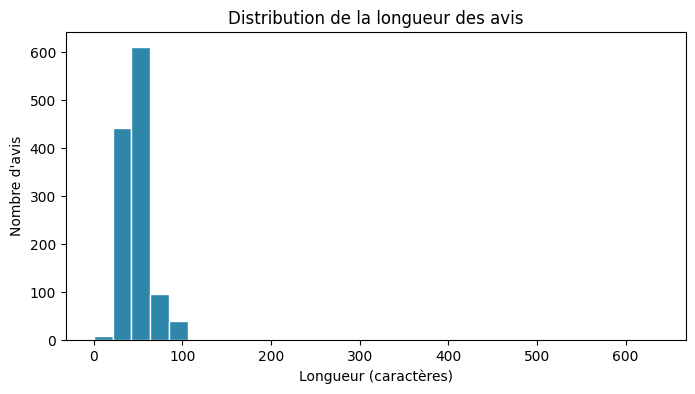

In [10]:
# Question 8 : Distribution de la longueur des avis
plt.figure(figsize=(8, 4))
plt.hist(df['longueur'], bins=30, color="#2E86AB", edgecolor="white")
plt.title("Distribution de la longueur des avis")
plt.xlabel("Longueur (caractères)")
plt.ylabel("Nombre d'avis")
plt.show()

# a) Textes anormalement longs : oui, quelques avis dépassent largement la moyenne (voir queue à droite)
# b) Textes très courts : oui, une part visible d'avis a une longueur proche de 0


In [11]:
# Question 9 : Textes vides
textes_vides = df[df['texte'].fillna('').astype(str).str.strip() == ""]
print("Nombre de textes vides :", len(textes_vides))

textes_nuls = df[df['texte'].isnull()]
print("Nombre de textes manquants (NaN) :", len(textes_nuls))


Nombre de textes vides : 6
Nombre de textes manquants (NaN) : 5


In [ ]:
# Question 10 : Doublons sur le texte
doublons = df[df.duplicated(subset='texte', keep=False)]
print("Nombre de lignes en doublon (texte) :", len(doublons))

Nombre de lignes en doublon (texte) : 1036


In [13]:
# Question 11 et 12 : Équilibre des classes et classe majoritaire
print(df['sentiment'].value_counts())
print("\nClasse majoritaire :", df['sentiment'].value_counts().idxmax())
# Les classes ne sont pas parfaitement équilibrées : il faudra en tenir compte lors du split et de l'évaluation


sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

Classe majoritaire : positif


In [14]:
# Question 13 : Métriques de classification à envisager
# Vu le léger déséquilibre des classes, privilégier : precision, recall, F1-score (macro/weighted)
# et une matrice de confusion, plutôt que la seule accuracy.


In [15]:
# Question 14 : Détection de caractères particuliers
nb_emojis = df['texte'].fillna('').astype(str).apply(lambda t: len(re.findall(r'[\U0001F300-\U0001FAFF]', t)))
nb_urls = df['texte'].fillna('').astype(str).apply(lambda t: len(re.findall(r'http\S+', t)))
nb_hashtags = df['texte'].fillna('').astype(str).apply(lambda t: len(re.findall(r'#\w+', t)))
nb_mentions = df['texte'].fillna('').astype(str).apply(lambda t: len(re.findall(r'@\w+', t)))
nb_chiffres = df['texte'].fillna('').astype(str).apply(lambda t: len(re.findall(r'\d', t)))
nb_ponct_repetee = df['texte'].fillna('').astype(str).apply(lambda t: len(re.findall(r'([!?.]){2,}', t)))

print("Avis avec emojis :", (nb_emojis > 0).sum())
print("Avis avec URLs :", (nb_urls > 0).sum())
print("Avis avec hashtags :", (nb_hashtags > 0).sum())
print("Avis avec mentions :", (nb_mentions > 0).sum())
print("Avis avec chiffres :", (nb_chiffres > 0).sum())
print("Avis avec ponctuation répétée :", (nb_ponct_repetee > 0).sum())


Avis avec emojis : 192
Avis avec URLs : 143
Avis avec hashtags : 127
Avis avec mentions : 128
Avis avec chiffres : 142
Avis avec ponctuation répétée : 141


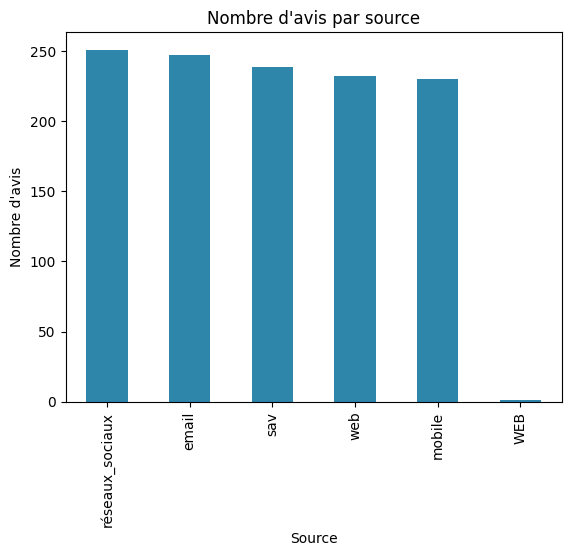

In [16]:
# Question 15 : Nombre d'avis par source
df['source'].value_counts().plot(kind='bar', color="#2E86AB")
plt.title("Nombre d'avis par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'avis")
plt.show()
# Commentaire : certaines sources (ex. web, mobile) fournissent plus d'avis que d'autres (ex. service client)
